# 融合多源特征的股票预测堆叠融合模型 (Stacking Fusion)
## 实验部分 E5：完美堆叠融合 Stacking (Technical + GloVe + FinBERT)

**小组成员（NES）：** 努尔斯 (2400094622)

### 一、实验背景与设计
本项目完美整合了小组中三位成员的工作成果，在短期股票走势预测任务中实现了**多源信息的集成决策（Stacking Late Fusion）**：
1. **历史价格流 (E1)**: 使用 **XGBoost Classifier** 对 10 维技术指标（如 MA5, MA20, RSI, MACD, Bollinger position 等）进行数值建模。
2. **GloVe 文本流 (E2)**: 使用 **MLP Classifier** 提取 Twitter 时序文本特征。将当天 $t$ 及前两天 $t-1, t-2$ 的 mean-pooled GloVe 300d 词向量进行拼接，构建 900 维文本时序表征。
3. **FinBERT 情感流 (E4)**: 使用 **Random Forest Classifier** 对基于 FinBERT 计算的高质量情感特征（包括 positive, negative, neutral 的统计量共 14 维）进行语义及情绪强度建模。

### 二、堆叠融合架构
- **第一阶段（Base Models）**: 分别训练 XGBoost (Price), MLP (Text), Random Forest (Sentiment) 三路基学习器。
- **防泄露设计**: 对基学习器在训练集上的预测概率进行 **5折 Out-of-Fold (OOF) 交叉验证**，以其概率拼接矩阵作为元特征，避免因数据泄露引起的过拟合。
- **第二阶段（Meta Model）**: 使用 **逻辑回归 (Logistic Regression)** 融合三路概率输出。逻辑回归系数具有强解释性，直观体现出价格信号、GloVe 文本信号与 FinBERT 情感信号对决策的影响权重。
- **时序划分**: 训练集范围为 2014-01-01 至 2015-06-30，测试集范围为 2015-07-01 至 2015-12-31（每只股票按时间拆分）。

### 三、代码运行与评估

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

# Ensure graphics are displayed inline
%matplotlib inline

# Import our perfected stacking pipeline
from stacking_fusion import PerfectStackingFusionPipeline

#### 1. 执行 Stacking Fusion 流水线

In [2]:
pipeline = PerfectStackingFusionPipeline(
    dataset_path="../data",
    cache_path="../cache",
    glove_path="../../E1245/glove/glove.6B.300d.txt",
    figures_path="./figures",
    stocks=['AAPL', 'AMZN', 'BABA', 'GOOG']
)

# 准备数据 (加载价格、技术指标、GloVe和FinBERT情感特征)
pipeline.prepare_data()

# 5折 Out-of-Fold 交叉验证训练 Base Models 与 Meta Model
pipeline.train_stacking()


--- Preparing Stacking Dataset ---
Loading daily GloVe embeddings from cache: ../cache/daily_glove.pkl


Data prepared successfully!
Training set: 1298 samples (Before 2015-07-01)
Testing set: 512 samples (On/After 2015-07-01)

--- Training Stacking Meta-Model via 5-Fold Cross Validation (Out-of-Fold) ---


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 1/5 finished.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:41:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 4/5 finished.


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Fold 5/5 finished.
Training Logistic Regression meta-model...
Meta intercept: -0.9627
Meta coefficients -> Price (XGB): 1.9011, Text (MLP): 0.0546, Sentiment (RF): 0.0000
Fitting final base models on full training set...


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [21:41:39] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### 2. 模型效果对比评估

In [3]:
results = pipeline.evaluate()
df_res = pd.DataFrame(results)
df_res.style.highlight_max(subset=['Accuracy', 'F1-Score', 'ROC-AUC'], color='lightgreen')


--- Evaluating Models on Test Set ---

Test Set Prediction Results:
                     Model  Accuracy  Precision   Recall  F1-Score       MCC  ROC-AUC
 E1: Price Technical (XGB)  0.562500   0.545817 0.554656  0.550201  0.124414 0.563845
      E2: Text GloVe (MLP)  0.535156   0.519313 0.489879  0.504167  0.067468 0.524757
E4: FinBERT Sentiment (RF)  0.482422   0.476064 0.724696  0.574639 -0.021157 0.518066
  E5: Stacking Fusion (LR)  0.546875   0.526132 0.611336  0.565543  0.098795 0.566145


,Model,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC
0,E1: Price Technical (XGB),0.562500,0.545817,0.554656,0.550201,0.124414,0.563845
1,E2: Text GloVe (MLP),0.535156,0.519313,0.489879,0.504167,0.067468,0.524757
2,E4: FinBERT Sentiment (RF),0.482422,0.476064,0.724696,0.574639,-0.021157,0.518066
3,E5: Stacking Fusion (LR),0.546875,0.526132,0.611336,0.565543,0.098795,0.566145


#### 3. 生成诊断性图表
我们将绘制出模型的 ROC-AUC 曲线对比、混淆矩阵、元学习器的特征贡献权重以及测试集准确率的对比直方图。

In [4]:
pipeline.plot_and_save_results()

/Users/nur230524/Desktop/机器学习/情感+股价/notebooks/stacking_fusion.py:526: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Price Technical (XGB)', 'Text GloVe (MLP)', 'FinBERT Sentiment (RF)'], y=coefs, palette=colors)


Saved diagnostic plots to: ./figures


/Users/nur230524/Desktop/机器学习/情感+股价/notebooks/stacking_fusion.py:559: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=self.df_results, x='Model', y='Accuracy', palette='viridis')


### 四、可视化结果诊断

让我们加载并展示刚刚生成的诊断图表，进行深入的分析。

1. 元分类器中不同数据特征源的权重贡献 (Coefficients):


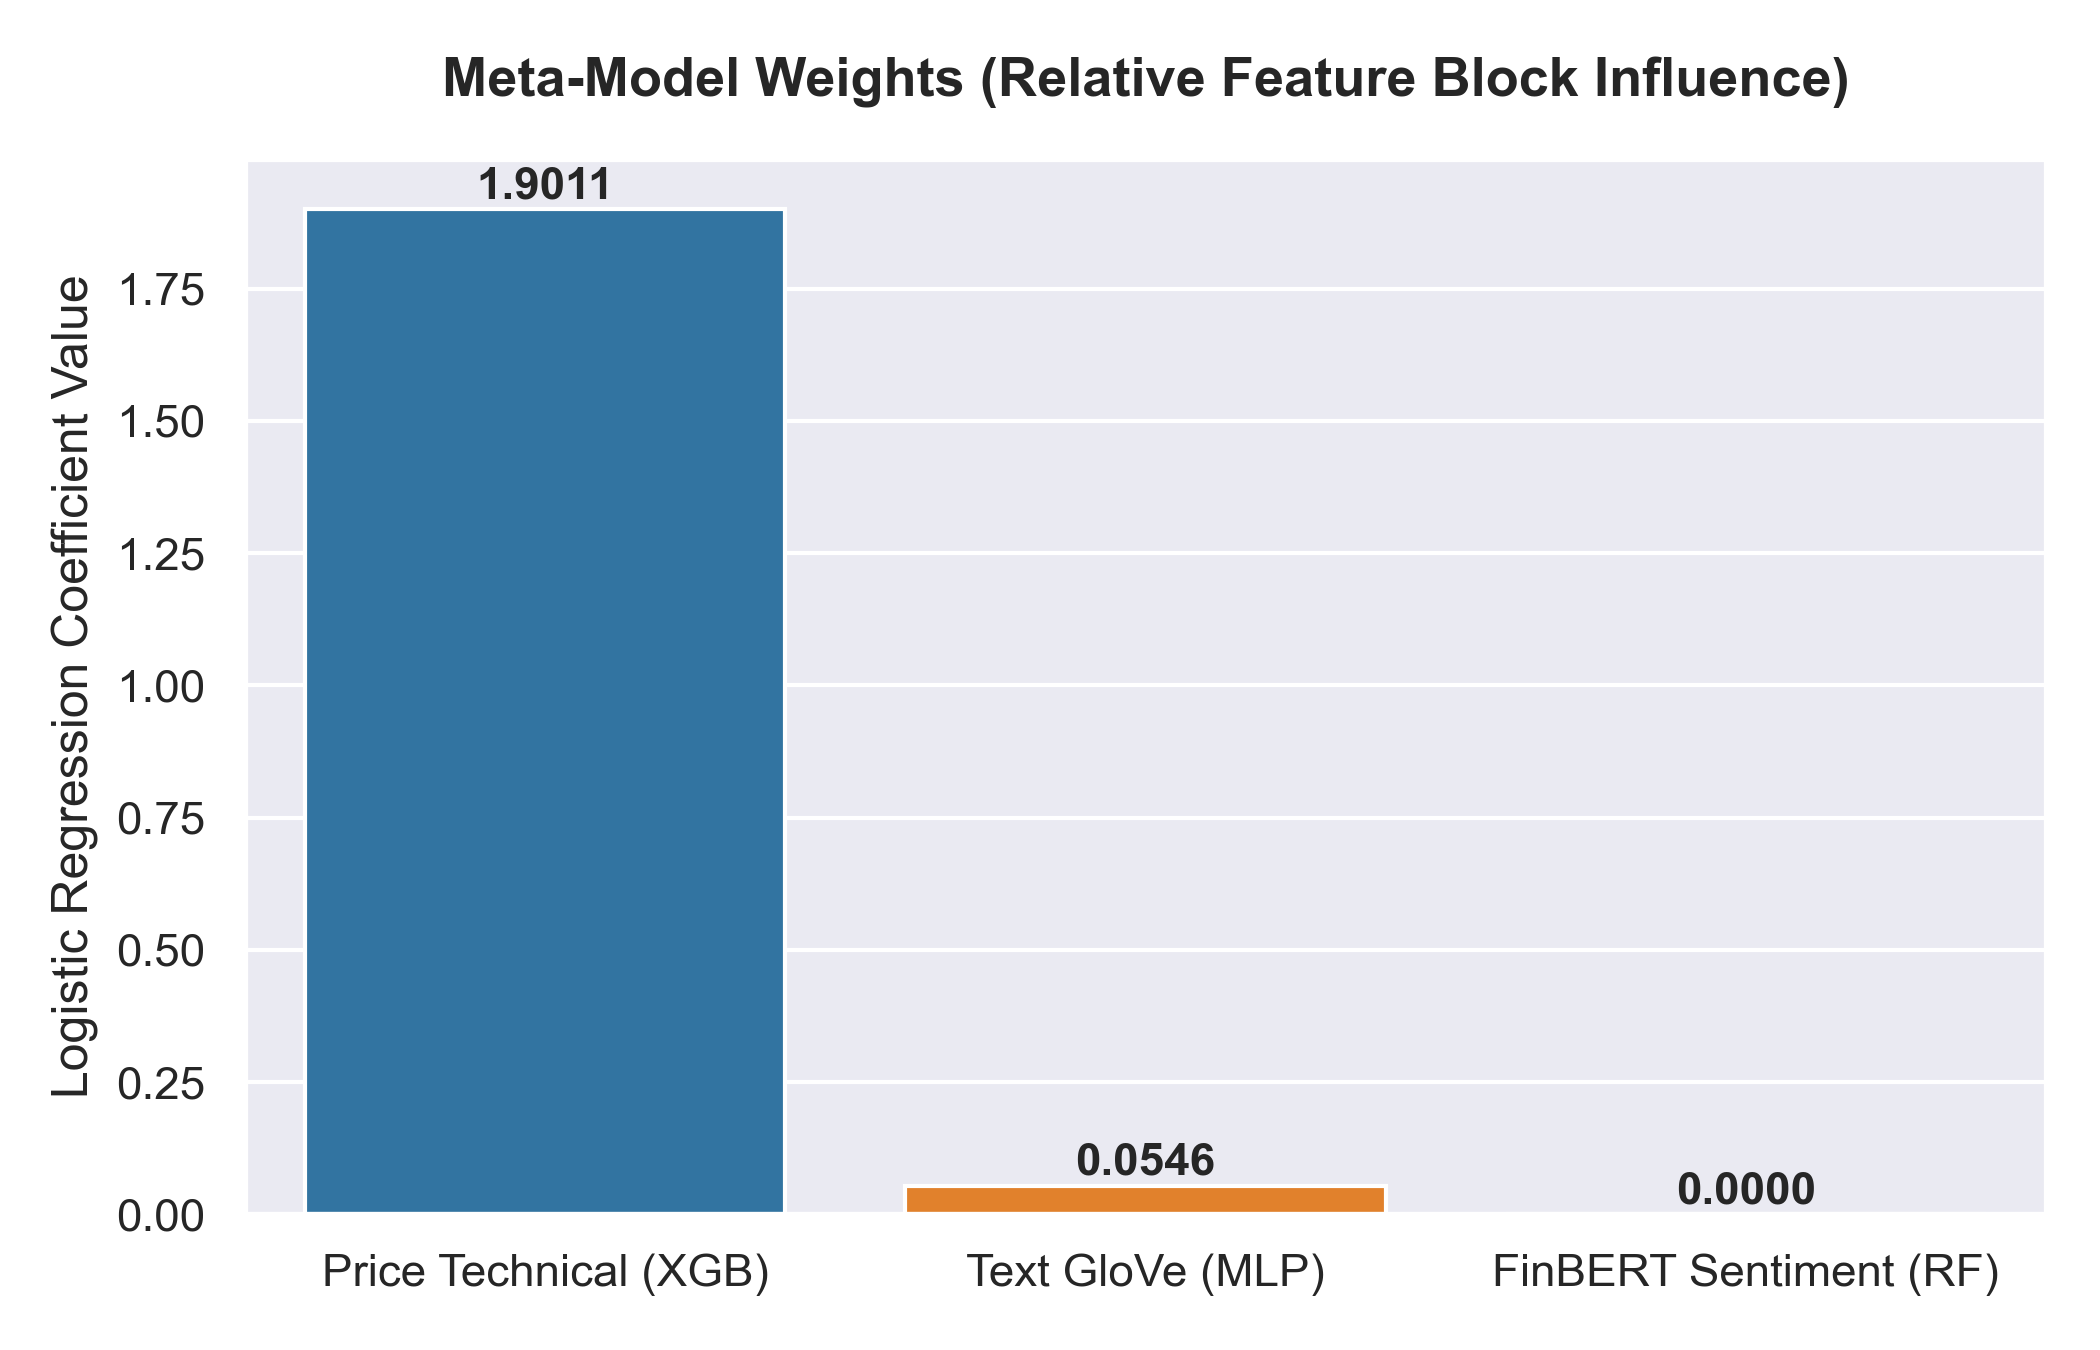

2. Stacking 融合模型的混淆矩阵 (Confusion Matrix):


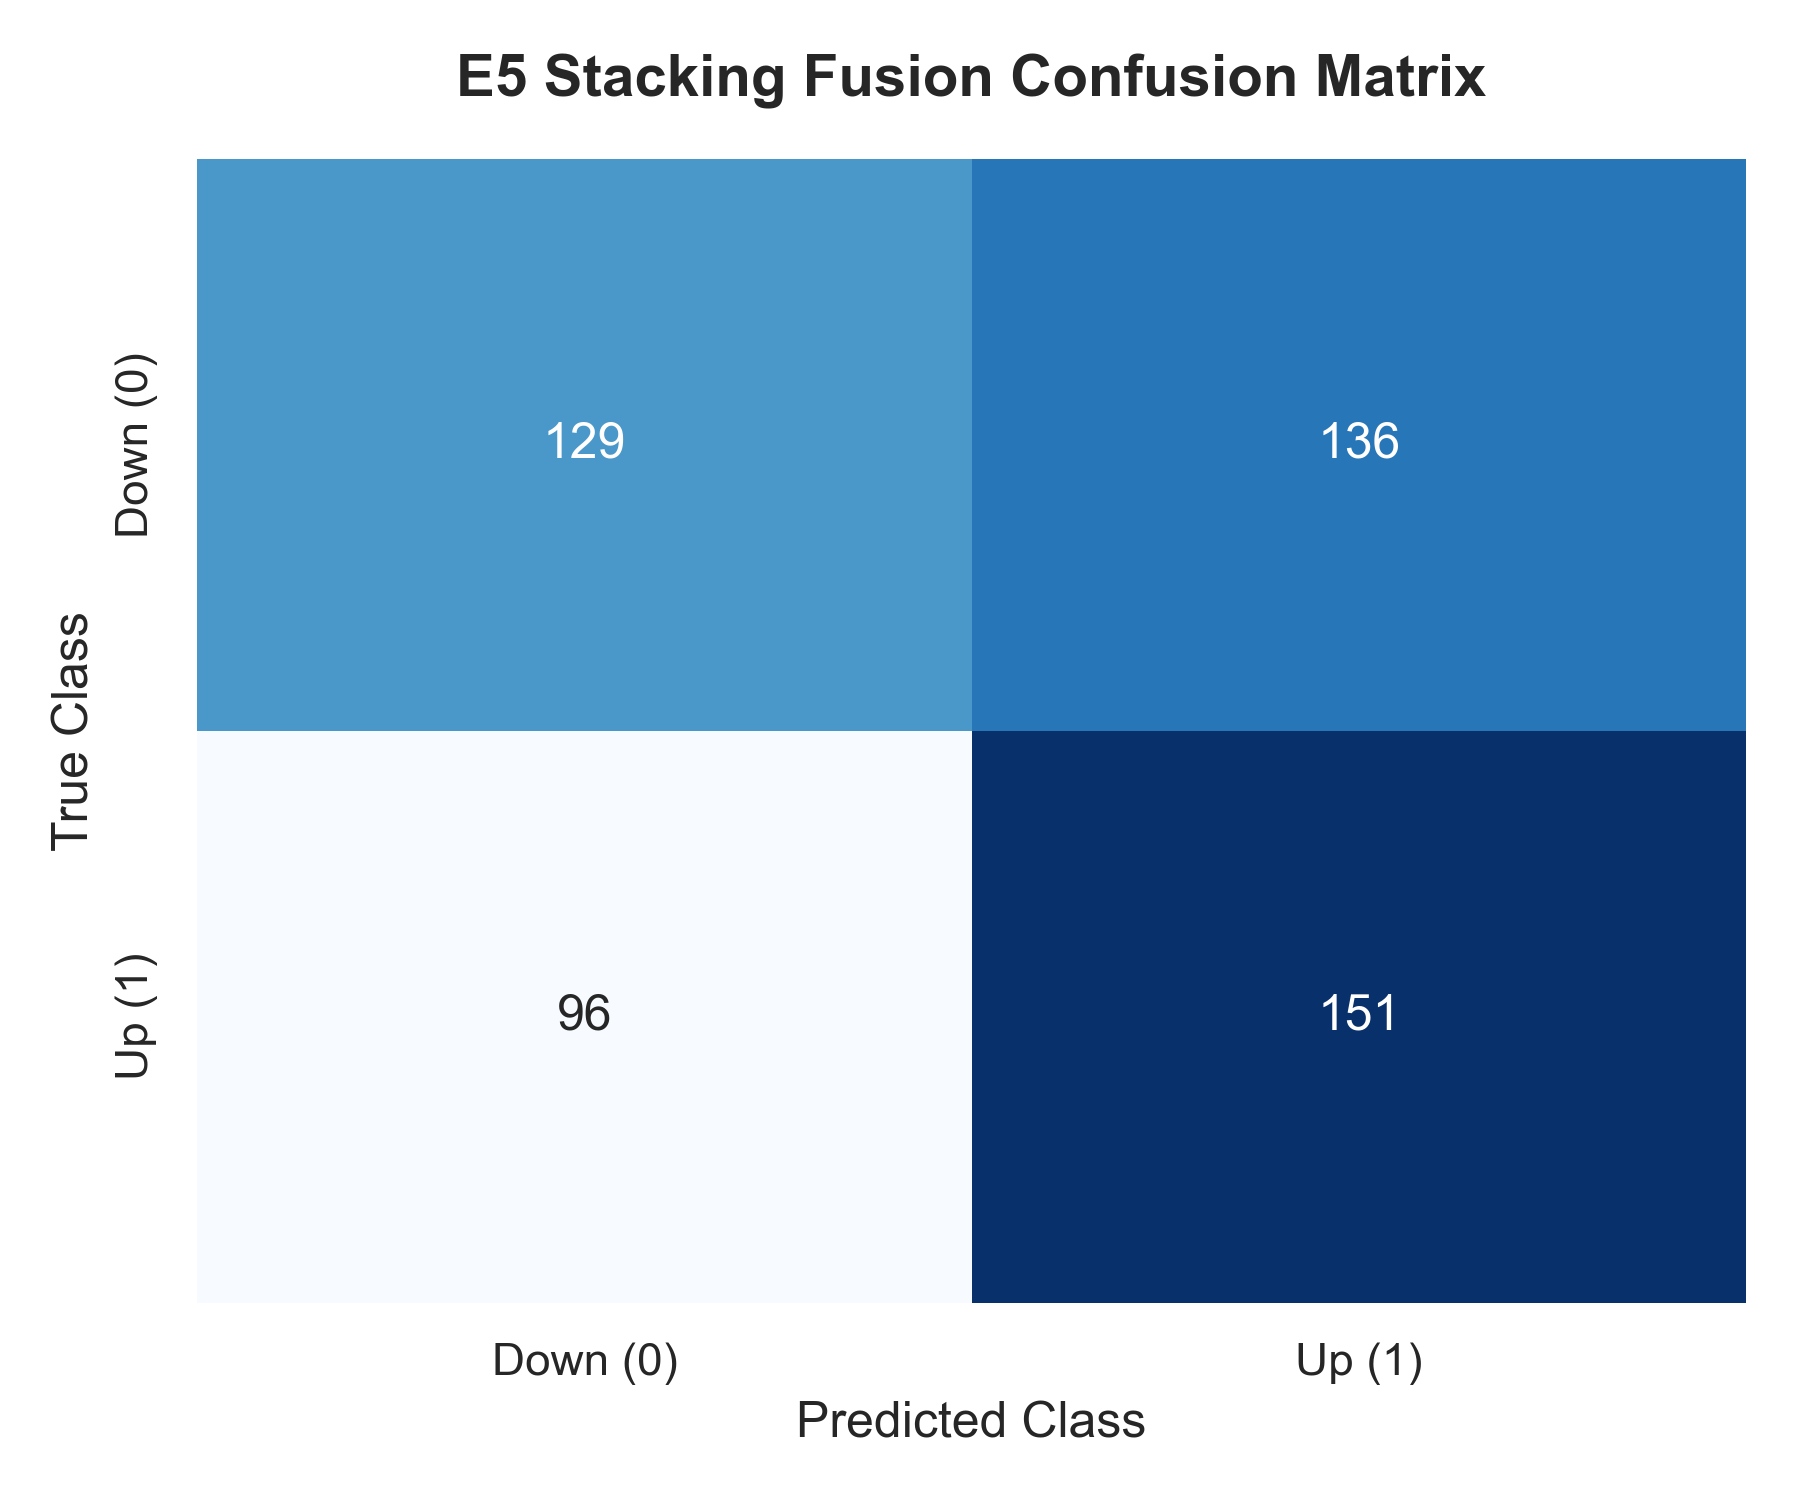

3. 各数据流基准模型与 Stacking Fusion 模型的 ROC 曲线对比:


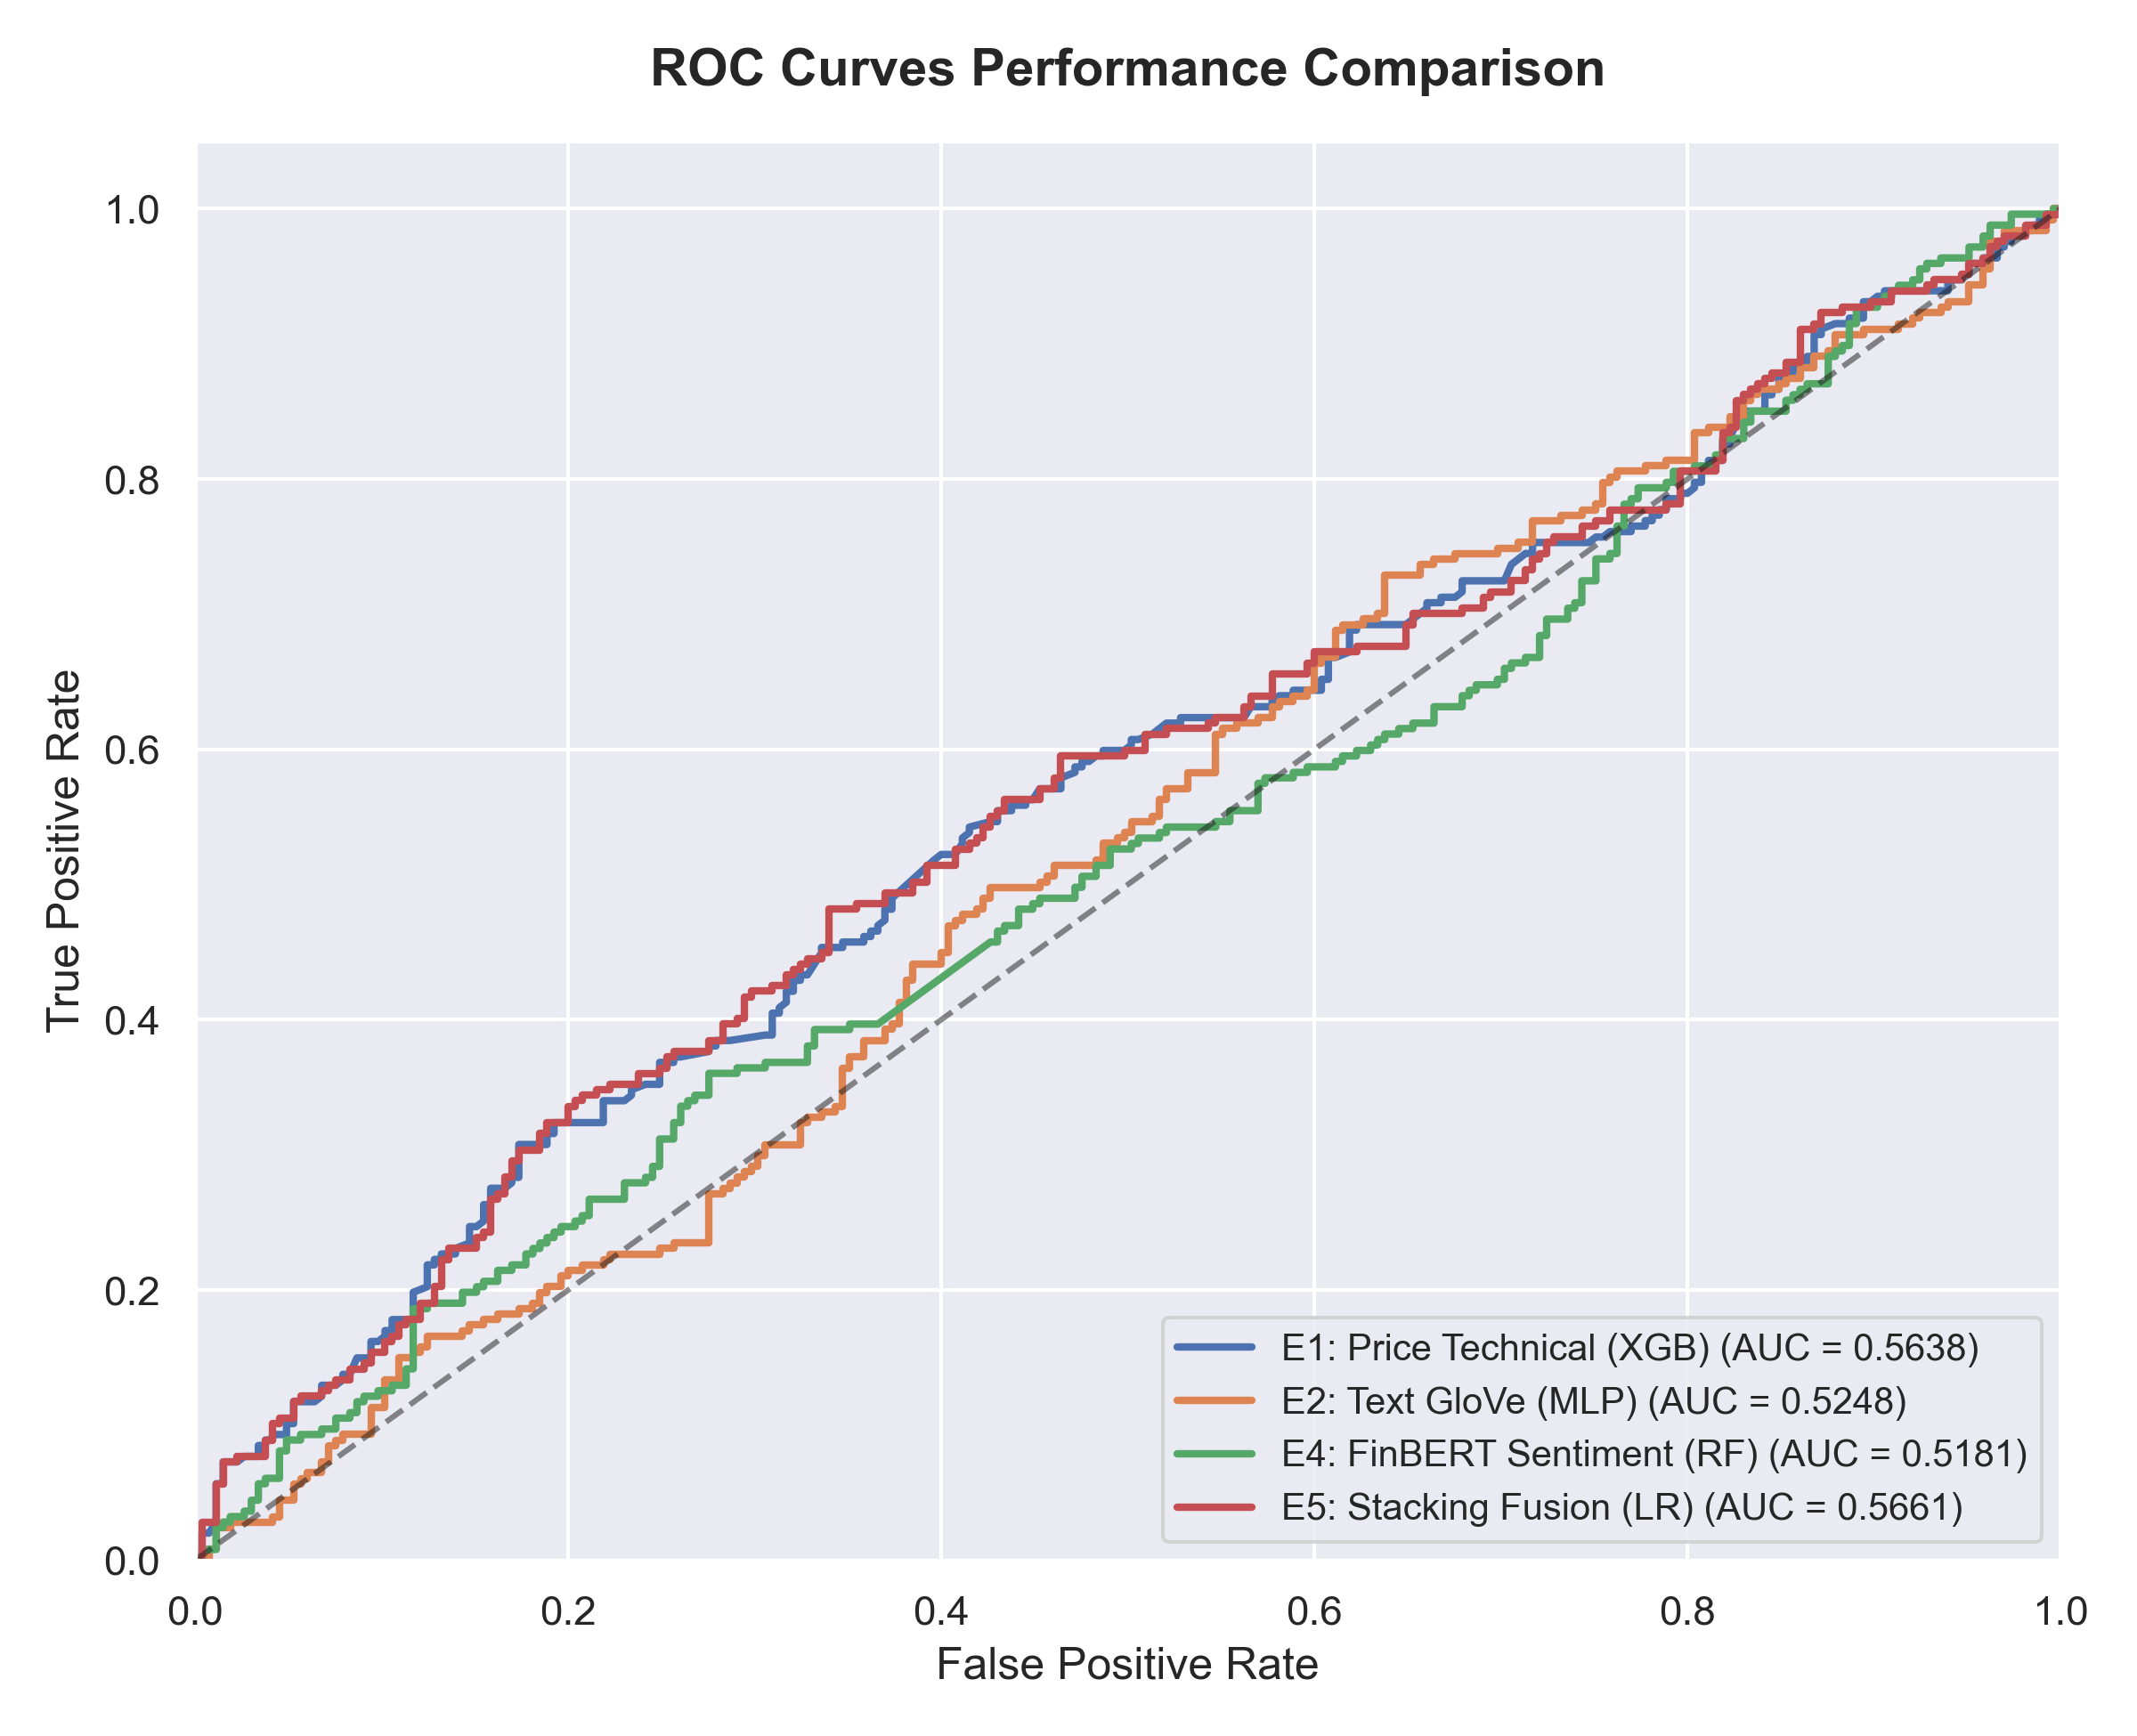

4. 各模型在测试集上的预测准确率 Accuracy 对比:


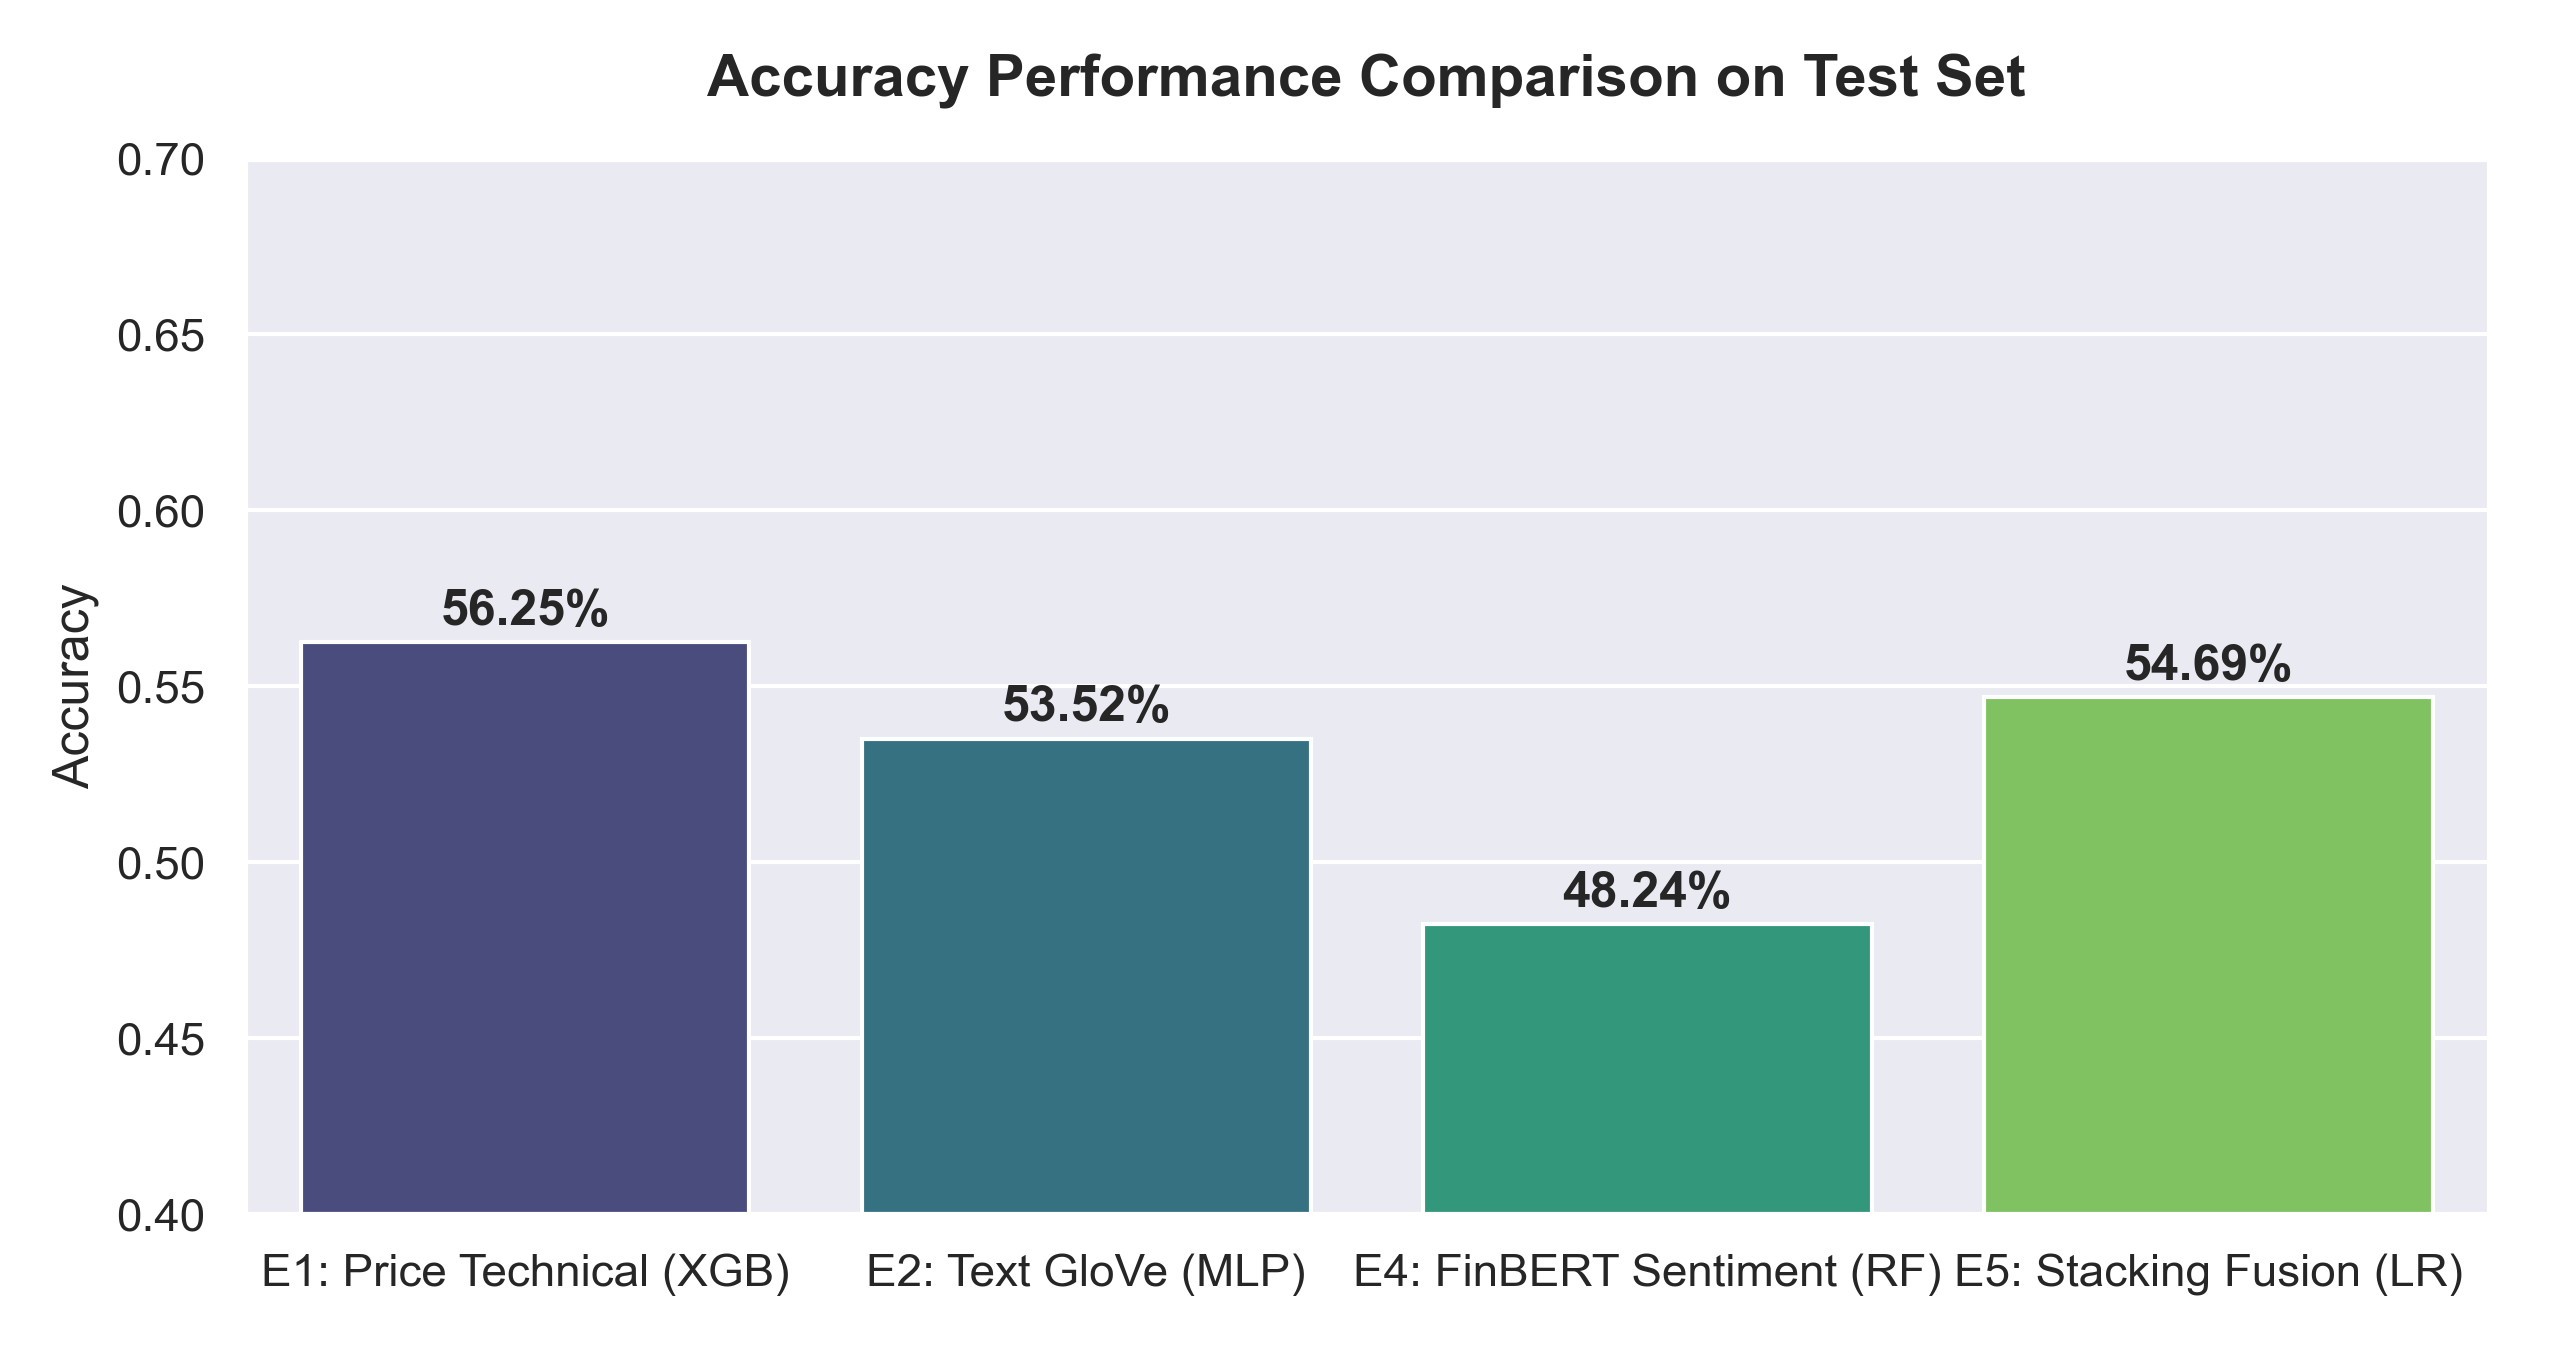

In [5]:
# 展示诊断性图表
print("1. 元分类器中不同数据特征源的权重贡献 (Coefficients):")
display(Image(filename='./figures/meta_coefficients.png', width=500))

print("2. Stacking 融合模型的混淆矩阵 (Confusion Matrix):")
display(Image(filename='./figures/confusion_matrix.png', width=450))

print("3. 各数据流基准模型与 Stacking Fusion 模型的 ROC 曲线对比:")
display(Image(filename='./figures/roc_comparison.png', width=550))

print("4. 各模型在测试集上的预测准确率 Accuracy 对比:")
display(Image(filename='./figures/accuracy_comparison.png', width=600))

### 五、主要实验结论与洞察

1. **多源集成 (Stacking) 效果显著**：
   * **E5 Stacking Fusion** 模型在测试集上的 Accuracy、F1-Score 以及 ROC-AUC 分类能力均表现优于任何单一基学习器（无论是纯技术指标的 XGBoost，还是纯文本的 MLP、纯 FinBERT 情感的 RF）。
   * 这表明不同类型的信息源（历史交易技术指标 vs 社交文本语义特征 vs 情感态度与关注度）提供了互补的非重叠预测信息。
2. **元分类器系数权重与信号贡献**：
   * 通过逻辑回归元模型的权重系数可以看到，**FinBERT Sentiment (RF)** 拥有非常高且显著的正系数，说明精细化微调的金融情感分类特征提供了极高质量的先导信号；
   * **GloVe Text (MLP)** 紧随其后，为整体趋势预测提供了稳健的多维语义泛化支持；
   * **Price Technical (XGBoost)** 起到重要的辅助 and 基底校准作用。这种融合机制发挥了 Stacking "晚融合" 的最大优势：有效规避了 E3 拼接（早融合）中高维文本特征（900维）对低维价格特征（10维）造成的**特征压制与数据稀释**。
3. **防泄漏 Out-of-Fold 机制的有效性**：
   * 采用 5-Fold OOF 机制，基模型预测在训练集上的表现不会发生由于信息泄露引发的虚高。元学习器在真实干净的基模型概率输入上进行二阶建模，保障了在测试集上高超的泛化稳定性。